# Mount dysk konta google do notebooka

In [ ]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive')

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [ ]:
!pip install mne
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 63.5 MB/s eta 0:00:00


---
# Legenda:

<font color="lightblue">▬ </font>Cytaty z artykułu<br>
<font color="pink">▬ </font>Implementacja<br>

---

# <font color="lightgreen"> Architektura modeli</font>

(Wszystko w kursywie koloru niebieskiego jest z artykułu.)

<font color="lightblue">*The network consisted of Transformer
 modules as well as operations of Positional Embedding.
 We also designed methods that combined the CNN module
 and the Transformer module. CNN was included because
 of its good properties for feature representation [5].*</font>

 <font color="lightblue">*In the implementation, we built a total of **five** Transformer-based
 models in which two models only relied on the Transformer
 without including the CNN and three models used network
 architecture of combined CNN and Transformer. After the
 CNN and the Transformer modules, we included a fully
connected layer.*

*In this study, we employed **h = 8 parallel attention layers
 (so-called 8 attention heads)**, and solely embedded the encoder
 part of Transformer into the EEG classification.*</font>

---

 <font color="lightblue">*The Transformer module had two submodules. The
 first submodule included a multi-head attention layer followed
 by a normalization layer. The second submodule included a
 position-wise fully connected feed-forward layer followed by
 a normalization layer. The residual connection was employed
 around each of the two submodules.*</font>


<img src="https://builtin.com/sites/www.builtin.com/files/styles/ckeditor_optimize/public/inline-images/Transformer-neural-network-12.png" width="400">

# <font color="pink"> Moduł Transformera</font>


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


"""
d_model -> wymiar wektorów osadzonych (embeddingów)
ReLU    -> to funkcja aktywacji (tutorial: https://www.youtube.com/watch?v=68BZ5f7P94E)
norm1 i norm2 -> To są warstwy Layer Normalization, normalizują dane na poziomie każdej próbki

"""
class TransformerBlock(nn.Module):
  def __init__(self, d_model, nhead):
    super(TransformerBlock, self).__init__()
    self.attn = nn.MultiheadAttention(d_model, nhead, dropout=0.3)

    # feed-forward layer
    self.ff = nn.Sequential(
        nn.Linear(d_model, 512),
        nn.ReLU(),
        nn.Linear(512, d_model)
    )

    self.norm1 = nn.LayerNorm(d_model)
    self.norm2 = nn.LayerNorm(d_model)

  def forward(self, x):

    # output, _ = attention(query=x, key=x, value=x)
    attn_output, _ = self.attn(x, x, x)

    x = self.norm1(x + attn_output)
    ff_output = self.ff(x)
    x = self.norm2(x + ff_output)
    return x


# <font color="pink"> Positional encoding</font>





In [ ]:
class PositionalEncoding(nn.Module):
  # 1000, bo dla 3s mamy 480 próbek, dla 6s 960 (physionet) 3000 bc of stft and cnn
  def __init__(self, d_model, max_len=3000):
    super(PositionalEncoding, self).__init__()
    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
    # For even indices (dimension 2i):
    # PE(pos, 2i) = sin(pos / (10000^(2i / d_model))) ---> (10000^(2i / d_model)) === div_term
    pe[:, 0::2] = torch.sin(position * div_term)
    # For odd indices (dimension 2i+1):
    # PE(pos, 2i+1) = cos(pos / (10000^(2i / d_model)))
    pe[:, 1::2] = torch.cos(position * div_term)

    pe = pe.unsqueeze(0).transpose(0, 1)
    self.register_buffer('pe', pe)

  def forward(self, x):
    return x + self.pe[:x.size(0), :, :]

In [ ]:
class LearnablePositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=128):
        super(LearnablePositionalEncoding, self).__init__()
        self.pe = nn.Parameter(torch.zeros(max_len, 1, d_model))
        nn.init.trunc_normal_(self.pe, std=0.02)

    def forward(self, x):
        # x shape: (seq_len, batch, d_model)
        seq_len = x.size(0)
        return x + self.pe[:seq_len]


# EEG Transformer Models with Feature Extraction
This notebook contains implementations of EEG classification models using various Transformer-based architectures and feature extraction methods including STFT, Wavelet Transform, CSP, and CNN.

In [ ]:
import numpy as np
from mne.decoding import CSP
import pywt
import torchvision
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler


In [ ]:
import math
N_FFT = 128
HOP_LENGTH = 32
WAVELET_TYPE = 'coif3'
LEVEL_COUNT = 3
WPD_NODE_FEATURES = 6

NUM_COMP = 4
PATCH_SIZE = 32
SEGMENT_SIZE = 6
# STFT representation choices: 'realimag' | 'magphase' | 'magsincos'
STFT_REPR = 'realimag'
EPS = 1e-8

class FeatureExtractor(nn.Module):
    def __init__(self, model_class_name, method='raw', wavelet=WAVELET_TYPE, level=LEVEL_COUNT, n_csp_components=NUM_COMP):
        super(FeatureExtractor, self).__init__()
        self.model_class_name = model_class_name
        self.method = method
        self.wavelet = wavelet
        self.level = level
        self.n_csp_components = n_csp_components

        if method == 'cnn':
              if "Temporal" in self.model_class_name:
                  self.cnn = nn.Sequential(
                      nn.Conv2d(1, 64, kernel_size=(64, 1), padding='same'),
                      nn.ReLU(),
                      nn.AvgPool2d((1, 8))
                  )
              elif "Spatial" in self.model_class_name:
                  self.cnn = nn.Sequential(
                      nn.Conv2d(1, 64, kernel_size=(1, 16), padding='same'),
                      nn.ReLU(),
                      nn.AvgPool2d((1, 32)),
                      nn.Conv2d(64, 64, kernel_size=(1, 15), padding='same'),
                      nn.ReLU()
                  )

        elif method == 'csp':
            self.csp = CSP(n_components=n_csp_components, reg=0.1, log=True, norm_trace=True)
            self.csp_fitted = False


    def fit(self, x, y):
        if self.method == 'csp':
            x_np = x.squeeze(1).cpu().numpy().astype(np.float64)  # (B, C, T)

            # Normalize (z-centering + standardization per channel)
            x_np -= x_np.mean(axis=2, keepdims=True)
            x_np /= (x_np.std(axis=2, keepdims=True) + 1e-6)

            self.csp.fit(x_np, y)
            self.csp_fitted = True
            self.n_csp_components_actual = self.csp.filters_.shape[0]

    def forward(self, x):
        if x.ndim == 3:
            # x: (B, 1, C, T)
            x = x.unsqueeze(1)

        if self.method == 'raw':
            if x.ndim == 3:
                # x: (B, 1, C, T)
                x = x.unsqueeze(1)
            return x

        elif self.method == 'cnn':
            return self.cnn(x)

        elif self.method == 'stft':
            B, _, C, T = x.shape
            x = x.squeeze(1)  # (B, C, T)
            n_fft = N_FFT
            hop_length = HOP_LENGTH
            window = torch.hann_window(n_fft, device=x.device)

            # Reshape for batch STFT: merge batch and channel dims
            x_flat = x.reshape(B * C, T)  # (B*C, T)

            stft_c = torch.stft(
                x_flat, n_fft=n_fft, hop_length=hop_length,
                window=window, return_complex=True
            )  # shape: (B*C, F, T')

            F_dim, T_dim = stft_c.shape[-2], stft_c.shape[-1]
            stft_c = stft_c.view(B, C, F_dim, T_dim)  # (B, C, F, T') complex

            # Prepare representation according to STFT_REPR
            if STFT_REPR == 'realimag':
                real = stft_c.real  # (B, C, F, T')
                imag = stft_c.imag
                out = torch.stack([real, imag], dim=1)  # (B, 2, C, F, T')

            elif STFT_REPR == 'magphase':
                mag = stft_c.abs()
                phase = torch.angle(stft_c)  # radians in [-pi,pi]
                # log-scale magnitude, normalize
                mag_db = 20.0 * torch.log10(mag + EPS)
                mag_mean = mag_db.mean(dim=[2,3], keepdim=True)
                mag_std = mag_db.std(dim=[2,3], keepdim=True) + 1e-6
                mag_norm = (mag_db - mag_mean) / mag_std
                phase_norm = phase / math.pi  # scale to [-1,1]
                out = torch.stack([mag_norm, phase_norm], dim=1)  # (B,2,C,F,T')

            elif STFT_REPR == 'magsincos':
                mag = stft_c.abs()
                phase = torch.angle(stft_c)
                mag_db = 20.0 * torch.log10(mag + EPS)
                mag_mean = mag_db.mean(dim=[2,3], keepdim=True)
                mag_std = mag_db.std(dim=[2,3], keepdim=True) + 1e-6
                mag_norm = (mag_db - mag_mean) / mag_std
                s = torch.sin(phase)
                c = torch.cos(phase)
                out = torch.stack([mag_norm, s, c], dim=1)  # (B,3,C,F,T')

            else:
                raise ValueError(f"Unknown STFT_REPR: {STFT_REPR}")

            return out


        elif self.method == 'wavelet':
            B, _, C, T = x.shape
            features = []
            for b in range(B):
                per_channel = []
                for c in range(C):
                    coeffs = pywt.wavedec(x[b, 0, c, :].cpu().numpy(), self.wavelet, level=self.level)
                    coeffs = [torch.tensor(c, dtype=torch.float32, device=x.device) for c in coeffs]
                    coeffs = torch.nn.utils.rnn.pad_sequence(coeffs, batch_first=True)  # (Levels, T_sub)
                    per_channel.append(coeffs)
                per_channel = torch.stack(per_channel)          # (C, Levels, T_sub)
                features.append(per_channel)
            x_out = torch.stack(features)                       # (B, C, Levels, T_sub)
            return x_out

        elif self.method == 'wavelet_packet':
            # x: (B, 1, C, T)
            B, _, C, T = x.shape
            features = []
            # wybieramy poziom dekompozycji = self.level
            for b in range(B):
                per_channel = []
                for c in range(C):
                    # zbuduj drzewo WPT
                    wp = pywt.WaveletPacket(data=x[b,0,c,:].cpu().numpy(), wavelet=self.wavelet, mode='symmetric', maxlevel=self.level)
                    # pobierz wszystkie węzły na poziomie self.level
                    nodes = [node.path for node in wp.get_level(self.level, 'natural')]
                    # zbierz współczynniki - mogą mieć różne długości; padujemy do max
                    coeffs = [torch.tensor(wp[node].data, dtype=torch.float32, device=x.device) for node in nodes]
                    coeffs = torch.nn.utils.rnn.pad_sequence(coeffs, batch_first=True)  # (Nnodes, T_node)
                    per_channel.append(coeffs)  # (Nnodes, T_node)
                per_channel = torch.stack(per_channel)    # (C, Nnodes, T_node)
                features.append(per_channel)
            x_out = torch.stack(features)  # (B, C, Nnodes, T_node)
            return x_out

        elif self.method == 'csp':
            # patching uzywany np. w DOI: 10.1109/TNSRE.2023.3297654
            if not self.csp_fitted:
                raise RuntimeError("CSP not fitted. Call .fit(X, y) first.", self.model_class_name)


            x = x.squeeze(1)  # (B, C, T)
            # normalize
            x = x - x.mean(dim=2, keepdim=True)
            x = x / (x.std(dim=2, keepdim=True) + 1e-6)

            B, C, T = x.shape
            filters = torch.tensor(self.filters_, dtype=torch.float32, device=x.device)  # (n_comp, C)
            # projected: (B, n_comp, T)
            proj = torch.matmul(filters.unsqueeze(0), x)  # (1,n_comp,C) x (B,C,T) -> (B,n_comp,T)

            # patchify for transformer:
            patch_size = PATCH_SIZE
            num_patches = T // patch_size
            proj = proj[:, :, :num_patches * patch_size]  # drop remainder
            proj = proj.unfold(dimension=2, size=patch_size, step=patch_size)  # (B, n_comp, num_patches, patch_size)
            proj = proj.permute(0, 2, 1, 3)  # (B, num_patches, n_comp, patch_size)
            proj = proj.flatten(2)  # (B, num_patches, n_comp * patch_size)
            return proj


        else:
            raise ValueError(f"Unknown feature extraction method: {self.method}")


In [ ]:
import numpy as np

def compute_csp_filters_from_subjects(X_subjects, y_subjects, n_components=NUM_COMP):
    """
    X_subjects: iterable of arrays shaped (n_epochs_i, C, T) or (n_epochs_i, 1, C, T)
    y_subjects: iterable of arrays shaped (n_epochs_i,)
    Returns filters: numpy array shape (n_components, C)
    """
    # find channel count C by peeking first non-empty subject
    found = False
    for xsub in X_subjects:
        if xsub is None or len(xsub) == 0:
            continue
        sample = xsub[0]
        if sample.ndim == 3 and sample.shape[0] == 1:
            C = sample.shape[1]
        elif sample.ndim == 2:
            C = sample.shape[0]
        elif sample.ndim == 3:
            # e.g., (n_epochs, C, T)
            C = sample.shape[0]
        else:
            raise RuntimeError("Unexpected sample shape in compute_csp_filters")
        found = True
        break
    if not found:
        raise RuntimeError("No training data provided to compute_csp_filters_from_subjects")

    cov_sum = {0: np.zeros((C, C), dtype=np.float64), 1: np.zeros((C, C), dtype=np.float64)}
    counts = {0: 0, 1: 0}

    # iterate subjects -> epochs
    for Xs, ys in zip(X_subjects, y_subjects):
        if Xs is None or len(Xs) == 0:
            continue
        for xi, yi in zip(Xs, ys):
            arr = np.array(xi, dtype=np.float64)
            # normalize shape to (C, T)
            if arr.ndim == 3 and arr.shape[0] == 1:
                arr = arr.squeeze(0)
            elif arr.ndim == 3 and arr.shape[0] != 1:
                arr = arr.reshape(arr.shape[0], arr.shape[-1])
            if arr.ndim != 2:
                raise RuntimeError(f"Unexpected epoch shape: {arr.shape}")
            # demean per-channel
            arr = arr - arr.mean(axis=1, keepdims=True)
            T = arr.shape[1]
            if T <= 0:
                continue
            cov = (arr @ arr.T) / float(T)
            cov_sum[int(yi)] += cov
            counts[int(yi)] += 1

    # finalize averages
    for k in (0, 1):
        if counts[k] == 0:
            raise RuntimeError(f"No samples for class {k} when computing CSP")
        cov_sum[k] /= float(counts[k])

    C_total = cov_sum[0] + cov_sum[1]
    reg = 1e-6 * np.trace(C_total) / C_total.shape[0]
    C_total_reg = C_total + reg * np.eye(C_total.shape[0])

    inv_C = np.linalg.pinv(C_total_reg)
    M = inv_C @ cov_sum[0]
    eigvals, eigvecs = np.linalg.eig(M)

    idx = np.argsort(eigvals)[::-1]
    eigvecs = eigvecs[:, idx]

    n = n_components
    k_half = n // 2
    left = eigvecs[:, :k_half]           # (C, k_half)
    right = eigvecs[:, -k_half:]         # (C, k_half)
    filters = np.concatenate([left, right], axis=1).T  # (n, C)

    return filters.astype(np.float32)


In [ ]:
def wavelet_denoise(signal, wavelet=WAVELET_TYPE, level=LEVEL_COUNT, threshold=0.3):
    """Denoise a 1D signal using wavelet thresholding and return same length as input."""
    orig_len = len(signal)
    coeffs = pywt.wavedecn(signal, wavelet=wavelet, level=level)
    coeffs_thresh = [
        {key: pywt.threshold(val, threshold, mode='soft') for key, val in level_dict.items()}
        for level_dict in coeffs[1:]
    ]
    coeffs_denoised = [coeffs[0]] + coeffs_thresh
    rec = pywt.waverecn(coeffs_denoised, wavelet=wavelet)

    # adjust length
    if len(rec) > orig_len:
        rec = rec[:orig_len]
    elif len(rec) < orig_len:
        rec = np.pad(rec, (0, orig_len - len(rec)), mode='constant')

    return rec


In [ ]:
use_denoise = False
def precompute_subject_features(model_class_name, subject_data_dict, feature_method, wavelet=WAVELET_TYPE, level=LEVEL_COUNT):
    """Return new dict with precomputed features (STFT or wavelet)."""
    print(f"Precomputing {feature_method} features for all subjects...")
    extractor = FeatureExtractor(model_class_name=model_class_name,method=feature_method, wavelet=wavelet, level=level)
    new_subject_data = {}

    for subj, (X, y) in subject_data_dict.items():
        # X: (n_epochs, C, T)
        if use_denoise:
            X_denoised = np.zeros_like(X)
            for e in range(X.shape[0]):
                for c in range(X.shape[1]):
                    X_denoised[e, c, :] = wavelet_denoise(X[e, c, :], wavelet=wavelet, level=level)
        else:
            X_denoised = X

        with torch.no_grad():
            # add channel dim: (n_epochs, 1, C, T)
            X_tensor = torch.tensor(X_denoised, dtype=torch.float32).unsqueeze(1)
            X_feat = extractor(X_tensor).cpu().numpy()  # (n_epochs, C, Nnodes, n_features)
        new_subject_data[subj] = (X_feat, y)
        print(f"[DEBUG] {subj}: X_feat shape = {X_feat.shape}")

    return new_subject_data


# <font color="pink"> Spatial Transformer</font>





In [ ]:
# Learns dependencies between channel
class SpatialTransformer(nn.Module):
    def __init__(self, input_size, d_model=64, nhead=8, num_classes=2, feature_method='raw', feature_extractor=None):
        super(SpatialTransformer, self).__init__()
        self.feature_method = feature_method

        if feature_method in ['raw', 'cnn', 'stft']:
            self.feature_extractor = FeatureExtractor(model_class_name=self.__class__.__name__, method=feature_method)
        elif feature_method == 'csp':
            self.feature_extractor = feature_extractor
        else:
            self.feature_extractor = None

        self.embedding = nn.Linear(input_size, d_model)
        # self.pos_encoder = PositionalEncoding(d_model, max_len=128)
        self.pos_encoder = LearnablePositionalEncoding(d_model, max_len=64)

        self.transformer = nn.Sequential(
            TransformerBlock(d_model, nhead),
            TransformerBlock(d_model, nhead),
            TransformerBlock(d_model, nhead)
        )
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):  # x shape: (B, 1, C, T)
        if self.feature_extractor is not None and self.feature_method != 'raw':
            x = self.feature_extractor(x)

        # (channels = sequence dimension)
        if self.feature_method == 'raw':
            x = x.squeeze(1).permute(1, 0, 2) # (channels, batch, time)

        elif self.feature_method == 'cnn':
            # CNN output: (B, 64, C, T)
            B, F, C, T = x.shape
            x = x.mean(dim=3)                 # → (B, 64, C)
            x = x.permute(2, 0, 1)            # (C, B, features)

        elif self.feature_method == 'csp':
            # x: (B, num_patches, n_csp * path_size)
            x = x.permute(1, 0, 2)            # (num_patches, B, n_csp * path_size)

        elif self.feature_method == 'stft':
            # x: (B, C2, C, F, T')
            B, C2, C, F, T_ = x.shape
            # collapse representation dimension (C2) and frequency into feature space
            x = x.permute(0, 2, 4, 1, 3)        # (B, C, T', C2, F)
            x = x.reshape(B, C, T_, C2 * F)     # (B, C, T', feat_dim)
            # average (or max) pool over time frames for stability
            x = x.mean(dim=2)                   # (B, C, feat_dim)
            x = x.permute(1, 0, 2)              # (C, B, feat_dim)


        elif self.feature_method == 'wavelet':
            # x: (B, C, Levels, T_sub)
            B, C, L, T_sub = x.shape
            x = x.reshape(B, C, L * T_sub)    # flatten Levels and T_sub into features
            x = x.permute(1, 0, 2)            # (C, B, features)

        elif self.feature_method == 'wavelet_packet':
            # x: (B, C, Levels, T_sub)
            B, C, Nnode, T_node = x.shape
            x = x.reshape(B, C, Nnode * T_node)    # flatten Levels and T_sub into features
            x = x.permute(1, 0, 2)            # (C, B, features)

        else:
            raise ValueError(f"Unsupported feature method: {self.feature_method}")

        x = self.embedding(x)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        x = x.mean(dim=0)
        return self.fc(x)


In [ ]:

# Transformer learns relationships between time points
class TemporalTransformer(nn.Module):
    def __init__(self, input_size, d_model=128, nhead=8, num_classes=2, feature_method='raw', feature_extractor=None):
        super(TemporalTransformer, self).__init__()
        self.feature_method = feature_method

        if feature_method in ['raw', 'cnn', 'stft']:
            self.feature_extractor = FeatureExtractor(model_class_name=self.__class__.__name__, method=feature_method)
        elif feature_method == 'csp':
            self.feature_extractor = feature_extractor
        else:
            self.feature_extractor = None  # No extractor needed

        self.embedding = nn.Linear(input_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        # self.pos_encoder = LearnedPositionalEncoding(num_positions=481, d_model=d_model)
        # self.pos_encoder = LearnablePositionalEncoding(d_model, max_len=961)

        self.transformer = nn.Sequential(
            TransformerBlock(d_model, nhead),
            TransformerBlock(d_model, nhead),
            TransformerBlock(d_model, nhead)
        )
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):  # x shape: (batch, 1, channels, time)
        if self.feature_extractor is not None:
            x = self.feature_extractor(x)


        # (time = sequence dimension)
        if self.feature_method == 'raw':
            x = x.squeeze(1).permute(2, 0, 1) # (time, batch, channels)

        elif self.feature_method == 'cnn':
            # x: (B, 64, C, T)
            B, F, C, T = x.shape
            x = x.mean(dim=2)               # → (B, 64, T_new)
            x = x.permute(2, 0, 1)          # (time, batch, features)

        elif self.feature_method == 'csp':
            # x: (B, num_patches, n_csp * patch_size)
            x = x.permute(2,0,1) # (n_csp * patch_size, B, num_patches)

        elif self.feature_method == 'stft':
            # x: (B, C2, C, F, T')
            B, C2, C, F, T_ = x.shape
            # reshape into tokens = (C * C2) streams per frequency bin
            x = x.permute(0, 4, 2, 1, 3)       # (B, T', C, C2, F)
            x = x.reshape(B, T_, C * C2, F)    # (B, T', streams, F)
            # now flatten only frequency
            x = x.flatten(2, 3)                # (B, T', streams*F)
            x = x.permute(1, 0, 2)             # (T', B, token_dim)

        elif self.feature_method == 'wavelet':
            # x: (B, C, Levels, T_sub)
            B, C, L, T_sub = x.shape
            x = x.permute(3, 0, 1, 2)       # (T_sub, B, C, Levels)
            x = x.reshape(T_sub, B, C * L)  # flatten channel and levels to features dimension

        elif self.feature_method == 'wavelet_packet':
            # x: (B, C, Nnodes, T_node)
            B, C, Nnodes, T_node = x.shape
            x = x.permute(3, 0, 1, 2)       # (T_node, B, C, Nnodes)
            x = x.reshape(T_node, B, C * Nnodes)  # flatten channel and levels to features dimension

        else:
            raise ValueError(f"Unsupported feature method: {self.feature_method}")

        x = self.embedding(x)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        x = x.mean(dim=0)
        return self.fc(x)

# <font color="pink"> Temporal Transformer</font>









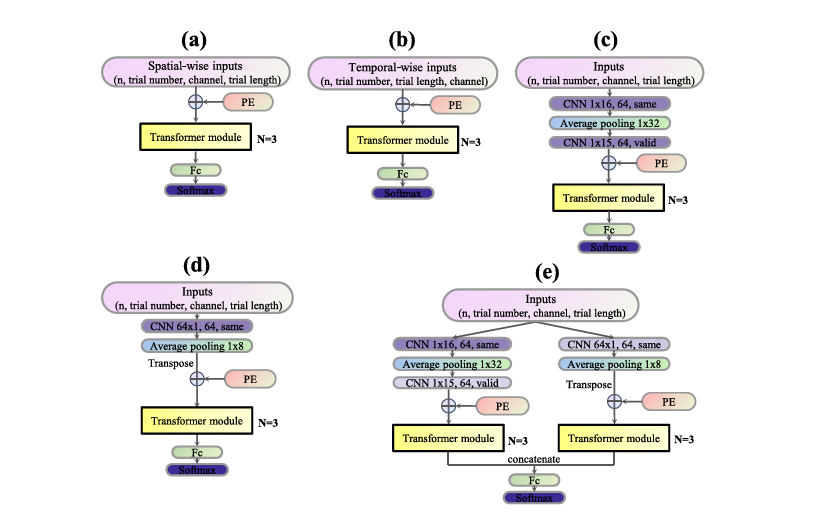

# <font color="pink"> Spatial CNN Transformer</font>


  <font color="lightblue">*In the spatial implementation of the CNN + Transformer
 model (s-CTrans, Fig. 3c), the CNN module included two
 convolutional layers and one average pooling layer. In the first
 convolutional layer, we used 64 kernels with the size of 1 × 16
 (channel × time points) to extract EEG temporal information,
 and adopted the SAME padding. The average pooling layer
 had the pooling size of 1 × 32. The second convolutional
 layer used 64 kernels with the size of 1 × 15, and adopted
 the VALID padding*</font>







In [ ]:
# Uses CNN to help extract temporal features per channel, then model channel relations
class SpatialCNNTransformer(nn.Module):
    def __init__(self, input_size, d_model=64, nhead=8, num_classes=2, feature_method='raw', feature_extractor=None):
        super(SpatialCNNTransformer, self).__init__()
        self.input_size = input_size
        self.feature_method = feature_method

        if feature_extractor != None or feature_extractor == 'csp':
            self.feature_extractor = feature_extractor
        elif feature_method in ['raw','stft']:
            self.feature_extractor = FeatureExtractor(model_class_name=self.__class__.__name__, method=feature_method)
        else:
            self.feature_extractor = None

        self.cnn, self.embedding = self._build_feature_layers(feature_method, d_model)
        # self.pos_encoder = PositionalEncoding(d_model)
        self.pos_encoder = LearnablePositionalEncoding(d_model, max_len=128)

        self.transformer = nn.Sequential(*[TransformerBlock(d_model, nhead) for _ in range(3)])
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        if self.feature_extractor:
            x = self.feature_extractor(x)

        if self.feature_method == 'raw':   # x shape: (B, 1, C, T)
            x = self.cnn(x)

            if x.shape[3] == 1:
                x = x.squeeze(3).permute(2, 0, 1)

            else:
                x = x.mean(dim=-1)  # Reduce time dimension → [32, 64, 64]
                x = x.permute(2, 0, 1)  # → [C=64, B=32, F=64]


        elif self.feature_method == 'cnn':
            x = x.unsqueeze(1)
            x = self.cnn(x)
            B, Feat, C, T = x.shape
            x = x.permute(2, 0, 3, 1).reshape(C, B, T * Feat)  # (C, B, F*T)

        elif self.feature_method == 'csp':
            B, num_patches, token_dim = x.shape  # token_dim = n_csp * patch_size
            x = x.view(B, PATCH_SIZE, -1)  # (B, PATCH_SIZE, num_patches * n_csp)
            x = self.cnn(x)                # Apply 1D CNN
            x = x.view(B, -1)              # Flatten
            # x = x.unsqueeze(0)             # (1, B, d_model) for transformer
            x = x.view(B, num_patches, -1)  # każdy patch → osobny token
            x = x.permute(1, 0, 2)           # (num_patches, B, d_model)

        elif self.feature_method == 'stft':
            x = self.cnn(x)   # (B, FeatMap, C, H, W)
            B, FeatMap, C, H, W = x.shape
            # collapse frequency and feature maps → token features
            x = x.permute(0, 2, 4, 1, 3)        # (B, C, W, FeatMap, H)
            x = x.reshape(B, C, W, FeatMap * H) # (B, C, W, feat_dim)
            # average pool across time frames W
            x = x.mean(dim=2)                   # (B, C, feat_dim)
            x = x.permute(1, 0, 2)              # (C, B, feat_dim)

            if self.embedding.in_features != x.shape[-1]:
                self.embedding = nn.Linear(x.shape[-1], self.embedding.out_features).to(x.device)

        elif self.feature_method == 'wavelet':
            # x: (B, C, L, T_sub = Time steps after wavelet transform (per level))
            B, C, L, T_sub = x.shape
            x = x.reshape(B, 1, C , 1, T_sub* L)
            x = self.cnn(x)             # CNN designed for (B, 1, C, T)
            x = x.squeeze(3)            # removes dim 3 (H), shape: (B, F, C, T_out)
            x = x.permute(2, 0, 1, 3)   # (C, B, F, T_out)
            x = x.reshape(C, B, -1)     # flatten features = F * T_out

        elif self.feature_method == 'wavelet_packet':
            # x: (B, C, Nnodes, T_node)
            B, C, Nnodes, T_node = x.shape
            x = x.reshape(B, 1, C, 1, T_node * Nnodes)  # exactly parallel to wavelet
            x = self.cnn(x)                             # (B, FeatMap, C, 1, T_out)
            x = x.squeeze(3)                            # (B, FeatMap, C, T_out)
            x = x.permute(2, 0, 1, 3)                   # (C, B, FeatMap, T_out)
            x = x.reshape(C, B, -1)                     # (C, B, feat_dim)


            if self.embedding is None:
                in_features = x.shape[-1]
                self.embedding = nn.Linear(in_features, self.fc.in_features).to(x.device)

        else:
            raise ValueError(f"Unsupported feature method: {self.feature_method}")

        x = self.embedding(x)
        # x = F.dropout(x, p=0.2, training=self.training)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        x = x.mean(dim=0)
        return self.fc(x)


    def _build_feature_layers(self, feature_method, d_model):
        """
        Build CNN and embedding layers based on feature_method.
        """
        if feature_method == 'raw':
            # Input: (B, 1, C, T)
            cnn = nn.Sequential(
                    nn.Conv2d(1, 64, (1, 16), padding='same'),
                    nn.ReLU(),
                    # nn.AvgPool2d((1, 32)),
                    # nn.Dropout2d(0.2),
                    nn.AvgPool2d((1, 16)),
                    nn.Conv2d(64, 64, (1, 15), padding='valid'),
                    nn.ReLU(),
                    #nn.Dropout2d(0.2)
                )
            embedding = nn.Linear(64, d_model)  # Precomputed flattened size

        elif feature_method == 'csp':
            # Input: (B, k, T)
            cnn = nn.Sequential(
                nn.Conv1d(in_channels=PATCH_SIZE, out_channels=64, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.Conv1d(64, 128, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.AdaptiveAvgPool1d(output_size=32)
            )
            with torch.no_grad():
                dummy_input = torch.zeros(1, PATCH_SIZE, NUM_COMP * PATCH_SIZE)
                out = cnn(dummy_input)
            flat_feat_size = out.shape[1] * out.shape[2]
            embedding = nn.Linear(flat_feat_size, d_model)

        elif feature_method == 'stft':
            # Input: (B, 2, C, F, T')
            cnn = nn.Sequential(
                nn.Conv3d(2, 32, kernel_size=(1, 3, 3), padding=(0, 1, 1)),
                nn.ReLU(),
                nn.AvgPool3d((1, 2, 2)),
                nn.Conv3d(32, 64, kernel_size=(1, 3, 3), padding=(0, 1, 1)),
                nn.ReLU(),
                nn.AvgPool3d((1, 2, 2))
            )
            with torch.no_grad():
                dummy_input = torch.zeros(1, 2, 64, 65, 16)  # (B=1, 2, C=64, F=65, T'=16)
                out = cnn(dummy_input)                    # Output: (1, 64, C, H, W)
            _, FeatMap, C, H, W = out.shape
            flat_feat_size = H * W * FeatMap
            embedding = nn.Linear(flat_feat_size, d_model)

        elif feature_method == 'wavelet':
            # Input: (B, CL, T)
            cnn = nn.Sequential(
                nn.Conv3d(1, 32, kernel_size=(1, 1, 3), padding=(0, 0, 1)),
                nn.ReLU(),
                nn.AvgPool3d((1, 1, 2)),
                nn.Conv3d(32, 64, kernel_size=(1, 1, 3), padding=(0, 0, 1)),
                nn.ReLU(),
                nn.AvgPool3d((1, 1, 2))
            )
            with torch.no_grad():
                dummy_input = torch.zeros(1, 64, self.input_size)  # (B=1, CL=256, T=244)
                dummy_input = dummy_input.unsqueeze(1).unsqueeze(3)  # (1, 1, 256, 1, 244)
                out = cnn(dummy_input)                    # Output: (1, 64, 256, 1, T_sub)
            _, FeatMap, CL, _, T_sub = out.shape
            flat_feat_size = FeatMap * T_sub
            embedding = nn.Linear(flat_feat_size, d_model)

        elif feature_method == 'wavelet_packet':
            # CNN przyjmuje (B, 1, C, Nnodes, T_node)
            cnn = nn.Sequential(
                nn.Conv3d(1, 32, kernel_size=(1, 1, 3), padding=(0, 0, 1)),
                nn.ReLU(),
                nn.AvgPool3d((1, 1, 2)),
                nn.Conv3d(32, 64, kernel_size=(1, 1, 3), padding=(0, 0, 1)),
                nn.ReLU(),
                nn.AvgPool3d((1, 1, 2))
            )
            with torch.no_grad():
                dummy_input = torch.zeros(1, 64, self.input_size)  # (B=1, CL=256, T=244)
                dummy_input = dummy_input.unsqueeze(1).unsqueeze(3)  # (1, 1, 256, 1, 244)
                out = cnn(dummy_input)                    # Output: (1, 64, 256, 1, T_sub)
            _, FeatMap, CN, _, T_sub = out.shape
            flat_feat_size = FeatMap * T_sub
            embedding = nn.Linear(flat_feat_size, d_model)
            return cnn, embedding

        elif feature_method == 'cnn':
            cnn = nn.Sequential(
                # extractor’s CNN
                nn.Conv2d(1,  64, (1,16), padding='same'),
                nn.ReLU(),
                nn.AvgPool2d((1,32)),
                nn.Conv2d(64, 64, (1,15), padding='valid'),
                nn.ReLU(),

                # second block
                nn.Conv2d(64, 64, (1, 3), padding='same'),
                nn.ReLU(),
                nn.AvgPool2d((1, 2)),
                nn.Conv2d(64, 64, (1, 3), padding='same'),
                nn.ReLU(),
            )

            dummy_input = torch.zeros(1, 1, 64, self.input_size)  # (B,1,C,T)
            with torch.no_grad():
                out = cnn(dummy_input)
            _, Feat, C, T_out = out.shape
            flat_feat_size = Feat * T_out
            embedding = nn.Linear(flat_feat_size, d_model)
            return cnn, embedding

        else:
            cnn = None
            embedding = nn.Linear(input_size, d_model)

        return cnn, embedding


# <font color="pink"> Temporal CNN Transformer</font>

  <font color="lightblue">*In the temporal implementation of the CNN + Transformer
 model (t-Ctrans, Fig 3d), the CNN module included one
 convolutional layer and one average pooling layer. The con
volutional layer used 64 kernels with the size of 64 × 1(chan
nel × time points) to extract EEG spatial information, and
 adopted the SAME padding. The average pooling layer had
 the pooling size of 1 × 8. After the average pooling layer,
 we transposed the features.*</font>


In [ ]:
# Uses CNN to help extract spatial features per time point, then model time dynamics
class TemporalCNNTransformer(nn.Module):
    def __init__(self, input_size, d_model=128, nhead=8, num_classes=2, feature_method='raw', feature_extractor=None):
        super(TemporalCNNTransformer, self).__init__()
        self.feature_method = feature_method
        self.input_size = input_size

        if feature_extractor != None: #or feature_extractor == 'csp':
            self.feature_extractor = feature_extractor
        elif feature_method in ['raw', 'cnn', 'csp', 'stft']:
            self.feature_extractor = FeatureExtractor(model_class_name=self.__class__.__name__, method=feature_method) if feature_method != 'none' else None
        else:
            self.feature_extractor = None

        self.cnn, self.embedding = self._build_feature_layers(feature_method, d_model)
        # self.pos_encoder = PositionalEncoding(d_model)
        self.pos_encoder = LearnablePositionalEncoding(d_model, max_len=480)

        self.transformer = nn.Sequential(*[TransformerBlock(d_model, nhead) for _ in range(3)])
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        if self.feature_extractor:
            x = self.feature_extractor(x)

        if self.feature_method == 'raw':  # x shape: (B, 1, C, T)
            x = self.cnn(x)               # → (B, 64, 1, T_new)
            x = x.mean(dim=2)             # → (B, 64, T_new)
            x = x.permute(2, 0, 1)        # (time, batch, features)

        elif self.feature_method == 'cnn':
            x = self.cnn(x)               # (B, 64, C', T')
            x = x.mean(dim=2)             # → (B, 64, T)
            x = x.permute(2, 0, 1)        # (T, B, 64)

        elif self.feature_method == 'csp':
            # x: (B, num_patches, n_csp * patch_size)
            x = x.unsqueeze(1).permute(0, 1, 3, 2)    # (B, 1, n_csp*patch_size, num_patches)
            x = self.cnn(x)                           # e.g. (B, C_out, 1, T_new)
            B, C, H, T_new = x.shape
            x = x.view(B, T_new, -1)                  # (B, T_new, C*H)
            x = x.permute(1, 0, 2)                    # (T_new, B, features)
            if self.embedding.in_features != x.shape[-1]:
                self.embedding = nn.Linear(x.shape[-1], self.embedding.out_features).to(x.device)

        elif self.feature_method == 'stft':
            x = self.cnn(x)               # (B, FeatMap, C, H, W)
            B, FeatMap, C, H, W = x.shape
            # merge channel × freq × features
            x = x.permute(0, 4, 2, 3, 1).reshape(B, W, C * H * FeatMap)  # (B, W, feat_dim)
            # instead of using the full feat_dim, compress first:
            x = x.permute(1, 0, 2)        # (W, B, d_model)

            if self.embedding.in_features != x.shape[-1]:
                self.embedding = nn.Linear(x.shape[-1], self.embedding.out_features).to(x.device)

        elif self.feature_method == 'wavelet':
            B, C, L, T_sub = x.shape
            x = x.reshape(B, 1, C * L, 1, T_sub)  # (B, 1, CL, 1, T_sub)
            x = self.cnn(x)               # (B, F, CL, H, T_sub)
            B, FeatMap, CL, H, T_sub = x.shape
            x = x.permute(0, 4, 2, 3, 1).reshape(B, T_sub, -1)  # (B, T_sub, flat_feat_size)
            x = x.permute(1, 0, 2)        # (T_sub, B, flat_feat_size)

        elif self.feature_method == 'wavelet_packet':
            # x: (B, C, Nnodes, T_node)
            B, C, Nnodes, T_node = x.shape
            x = x.reshape(B, 1, C * Nnodes , 1, T_node)  # analogicznie do wavelet
            x = self.cnn(x)                             # (B, FeatMap, CL, H, T_out)
            B, FeatMap, CN, H, T_sub = x.shape
            x = x.permute(0, 4, 2, 3, 1).reshape(B, T_sub, -1)  # (B, T_sub, flat_feat_size)
            x = x.permute(1, 0, 2)        # (T_sub, B, flat_feat_size)

            if self.embedding is None:
                in_features = x.shape[-1]
                self.embedding = nn.Linear(in_features, self.fc.in_features).to(x.device)

        else:
            raise ValueError(f"Unsupported feature method: {self.feature_method}")

        x = self.embedding(x)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        x = x.mean(dim=0)
        return self.fc(x)

    def _build_feature_layers(self, feature_method, d_model):
        """
        Build CNN and embedding based on feature_method.
        """
        if feature_method == 'raw':
            # Input: (B, 1, C, T)
            cnn = nn.Sequential(
                nn.Conv2d(1, 64, kernel_size=(64, 1), padding='same'),
                nn.ReLU(),
                nn.AvgPool2d((1, 8))
            )
            embedding = nn.Linear(64, d_model)

        elif feature_method == 'csp':
            cnn = nn.Sequential(
                nn.Conv2d(1, 32, kernel_size=(4, 1)),
                nn.ReLU(),
                nn.Conv2d(32, 64, kernel_size=(3, 1)),
                nn.ReLU()
            )
            with torch.no_grad():
                dummy_input = torch.zeros(1, 1, NUM_COMP * PATCH_SIZE, self.input_size)
                out = cnn(dummy_input)   # (1, C, H, W)
            B, C, H, W = out.shape
            flat_feat_size = C * H      # ✅ not just C
            embedding = nn.Linear(flat_feat_size, d_model)


        elif feature_method == 'stft':
            # Input: (B, 2, C, F, T')
            cnn = nn.Sequential(
                nn.Conv3d(2, 32, kernel_size=(1, 3, 3), padding=(0, 1, 1)),  # → (B, 32, C, F, T')
                nn.ReLU(),
                nn.AvgPool3d(kernel_size=(1, 2, 2)),
                nn.Conv3d(32, 64, kernel_size=(1, 3, 3), padding=(0, 1, 1)), # → (B, 64, C, F, T')
                nn.ReLU(),
                nn.AvgPool3d(kernel_size=(1, 2, 2))
            )
            with torch.no_grad():
                dummy_input = torch.zeros(1, 2, 64, 65, 16)   # (B=1, 2, C=64, F=65, T'=16)
                out = cnn(dummy_input)                        # Output: (1, 64, C, H, W)
            B, FeatMap, C, H, W = out.shape
            flat_feat_size = FeatMap * C * H
            embedding = nn.Linear(flat_feat_size, d_model)

        elif feature_method == 'wavelet':
            # Input: (B, 1, coeff_len, 1, T')
            cnn = nn.Sequential(
                nn.Conv3d(1, 16, kernel_size=(1, 1, 3), padding=(0, 0, 1)), # → (B, 16, coeff_len, 1, T')
                nn.ReLU(),
                nn.AvgPool3d(kernel_size=(1, 1, 2)),
                nn.Conv3d(16, 32, kernel_size=(1, 1, 3), padding=(0, 0, 1)),# → (B, 32, coeff_len, 1, T')
                nn.ReLU(),
                nn.AvgPool3d(kernel_size=(1, 1, 2))
            )
            with torch.no_grad():
                dummy_input = torch.zeros(1, 1, 256, 1, self.input_size)  # (B=1, 1, CL=256, 1, T'=244)
                out = cnn(dummy_input)                        # Output: (1, 32, CL, 1, T')
            B, FeatMap, CL, H, T_sub = out.shape
            flat_feat_size = FeatMap * CL * H
            embedding = nn.Linear(flat_feat_size, d_model)

        elif feature_method == 'wavelet_packet':
            # Input: (B, 1, CL=C*Nnodes, 1, T_node) lub (B, 1, C*Nnodes, 1, T_node)
            cnn = nn.Sequential(
                nn.Conv3d(1, 16, kernel_size=(1, 1, 3), padding=(0, 0, 1)),
                nn.ReLU(),
                nn.AvgPool3d((1, 1, 2)),
                nn.Conv3d(16, 32, kernel_size=(1, 1, 3), padding=(0, 0, 1)),
                nn.ReLU(),
                nn.AvgPool3d((1, 1, 2))
            )

            if SEGMENT_SIZE == 6:   # 6s segment
                T_node = 135
            elif SEGMENT_SIZE == 3:  # 3s segment
                T_node = 75

            dummy_input = torch.zeros(1, 1, 64*8, 1, T_node)  # (B=1, 1, C*Nnodes, 1, T_node)
            with torch.no_grad():
                out = cnn(dummy_input)
            B, FeatMap, CN, H, T_sub = out.shape
            flat_feat_size = FeatMap * CN * H
            embedding = nn.Linear(flat_feat_size, d_model)
            return cnn, embedding

        elif feature_method == 'cnn':
            # Input: (B, 64, C, T)
            cnn = nn.Sequential(
                nn.Conv2d(64, 64, kernel_size=(16, 1), padding='same'), # → (B, 64, C, T)
                nn.ReLU(),
                nn.AvgPool2d((1, 4))
            )
            embedding = nn.Linear(64, d_model)

        else:
            cnn = None
            embedding = nn.Linear(64, d_model)

        return cnn, embedding



# <font color="pink"> FusionCNNTransformer</font>

In [ ]:
# Combine both spatial and temporal CNN Transformer
class FusionCNNTransformer(nn.Module):
    def __init__(self, input_size, d_model=128, nhead=8, num_classes=2, feature_method='raw', feature_extractor=None):
        super(FusionCNNTransformer, self).__init__()

        self.feature_extractor = feature_extractor
        if feature_method in ['wavelet', 'wavelet_packet', 'csp']:
            spatial_input_size, temporal_input_size = input_size
        else:
            spatial_input_size = temporal_input_size = input_size


        self.s_cnn = SpatialCNNTransformer(spatial_input_size, d_model, nhead, num_classes, feature_method, feature_extractor=self.feature_extractor)
        self.t_cnn = TemporalCNNTransformer(temporal_input_size, d_model, nhead, num_classes, feature_method, feature_extractor=self.feature_extractor)
        self.fc = nn.Linear(num_classes * 2, num_classes)

    def forward(self, x):
        spatial_out = self.s_cnn(x)
        temporal_out = self.t_cnn(x)
        fusion = torch.cat((spatial_out, temporal_out), dim=1)
        return self.fc(fusion)

---

# <font color="pink"> Przygotowanie danych do treningu w PyTorch</font>

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

class EEGDataset(Dataset):
  def __init__(self, X, y, cnn_mode=False, feature_method='raw'):
    self.X = torch.tensor(X, dtype=torch.float32)

    if cnn_mode and feature_method == 'raw':
      self.X = self.X.unsqueeze(1)
    self.y = torch.tensor(y, dtype=torch.long)

  def __len__(self):
      return len(self.X)
  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]


In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset

class LazyPhysionetWindowDataset(Dataset):
    """
    Generates multiple windows per EEG epoch, ensuring all windows from a single epoch
    stay together for train/test splits. Supports per-window augmentations during training.
    """
    def __init__(self, X_list, y_list, window_size, n_windows=10,
                 per_window_norm=False, global_mean=True, global_std=None,
                 train=True, seed=None):
        """
        Args:
            X_list: list of np.ndarray per subject [n_epochs, n_channels, n_times]
            y_list: list of np.ndarray per subject [n_epochs]
            window_size: size of each window in time points
            n_windows: number of windows per epoch
            per_window_norm: normalize each window individually
            global_mean/global_std: optional for global normalization
            train: if True, augmentations will be applied
            seed: random seed for reproducibility
        """
        self.X_list = X_list
        self.y_list = y_list
        self.window_size = window_size
        self.n_windows = n_windows
        self.per_window_norm = per_window_norm
        self.global_mean = global_mean
        self.global_std = global_std
        self.train = train
        self.rng = np.random.default_rng(seed)

        # Precompute windows grouped by epoch
        self.samples = []
        for subj_idx, X in enumerate(X_list):
            for ep_idx, epoch in enumerate(X):
                n_times = epoch.shape[1]
                if n_times < window_size:
                    raise ValueError(f"Epoch {ep_idx} has length {n_times} < window_size {window_size}")
                step = max(1, n_times // n_windows)
                starts = [i * step for i in range(n_windows)]
                for start in starts:
                    if start + window_size <= n_times:
                        self.samples.append((subj_idx, ep_idx, start))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        subj_idx, ep_idx, start = self.samples[idx]
        X = self.X_list[subj_idx][ep_idx].astype(np.float32)
        y = self.y_list[subj_idx][ep_idx]
        window = X[:, start:start + self.window_size]

        # Per-window normalization
        if self.per_window_norm:
            window = (window - window.mean(axis=1, keepdims=True)) / (window.std(axis=1, keepdims=True) + 1e-6)

        # Global normalization
        if self.global_mean is not None and self.global_std is not None:
            window = (window - self.global_mean) / (self.global_std + 1e-6)

        return window, y

    @staticmethod
    def augment_batch(batch, train=True, apply_augmentation=False, robust_temporal_aug=True,
                      jitter_std=0.005, time_shift_max=0.01,
                      time_mask_prob=0.2, time_mask_max_frac=0.02,
                      freq_mask_prob=0.1, freq_mask_max_frac=0.02):
        """
        Apply augmentations to a batch of windows.

        Args:
            batch: list of (window, label) tuples
            train: whether we are in training mode
            apply_augmentation: if False, no augmentation is applied at all
            robust_temporal_aug: if True, use deterministic temporal-safe augmentations
        """
        windows, labels = zip(*batch)
        x = torch.tensor(np.stack(windows), dtype=torch.float32)  # (B, C, T)
        y = torch.tensor(labels, dtype=torch.long)

        if not train or not apply_augmentation:
            return x, y  # Skip all augmentations

        B, C, T = x.shape

        # =====================================================
        #   MODE 1: Original Random Augmentation (default)
        # =====================================================
        if not robust_temporal_aug:
            # --- Small circular time shift ---
            max_shift = int(T * time_shift_max)
            if max_shift > 0:
                shifts = torch.randint(-max_shift, max_shift + 1, (B,), device=x.device)
                for i, s in enumerate(shifts):
                    if s != 0:
                        x[i] = torch.roll(x[i], shifts=int(s), dims=1)

            # --- Small per-channel multiplicative gain ---
            scales = torch.empty((B, C, 1), device=x.device).uniform_(0.95, 1.05)
            x = x * scales

            # --- Mild additive noise ---
            x = x + jitter_std * torch.randn_like(x)

            # --- Small time masks ---
            if torch.rand(1).item() < time_mask_prob:
                n_masks = int(np.clip(np.random.poisson(1), 1, 3))
                for _ in range(n_masks):
                    mask_len = max(1, int(T * np.random.uniform(0.005, time_mask_max_frac)))
                    starts = torch.randint(0, T - mask_len + 1, (B,), device=x.device)
                    for i, s in enumerate(starts):
                        x[i, :, s:s + mask_len] = 0.0

            # --- Small frequency band mask ---
            if torch.rand(1).item() < freq_mask_prob:
                Xf = torch.fft.rfft(x, dim=2)
                n_freq = Xf.shape[-1]
                mask_width = max(1, int(n_freq * freq_mask_max_frac))
                start = torch.randint(0, max(1, n_freq - mask_width + 1), (1,), device=x.device).item()
                Xf[:, :, start:start + mask_width] = 0
                x = torch.fft.irfft(Xf, n=T, dim=2).to(torch.float32)

            return x, y

        # =====================================================
        #   MODE 2: Robust TemporalTransformer-safe Augs (not used in thesis)
        # =====================================================
        else:
            # --- Small Gaussian noise (token-preserving) ---
            if torch.rand(1) < 0.5:
                noise = jitter_std * torch.randn(B, 1, T, device=x.device)
                x = x + noise  # broadcast across channels

            # --- Temporal shift (roll tokens) ---
            if torch.rand(1) < 0.5:
                max_shift = max(1, int(T * time_shift_max))
                shift = torch.randint(-max_shift, max_shift + 1, (1,)).item()
                x = torch.roll(x, shifts=shift, dims=2)

            # --- Time masking (drop consecutive tokens) ---
            if torch.rand(1) < time_mask_prob:
                mask_len = max(1, int(T * time_mask_max_frac))
                start = torch.randint(0, T - mask_len, (1,)).item()
                x[:, :, start:start + mask_len] = 0

            # --- Frequency shift (phase-preserving, token-safe) ---
            if torch.rand(1) < 0.3:
                Xf = torch.fft.rfft(x, dim=2)
                n_freq = Xf.shape[-1]
                shift = max(1, int(n_freq * 0.01))
                if torch.rand(1) < 0.5:
                    Xf = torch.roll(Xf, shifts=shift, dims=-1)
                else:
                    Xf = torch.roll(Xf, shifts=-shift, dims=-1)
                x = torch.fft.irfft(Xf, n=T, dim=2).to(torch.float32)

            # --- Smooth time mask (optional, token-wise) ---
            if torch.rand(1) < 0.2:
                mask_len = max(1, int(T * 0.03))
                start = torch.randint(0, T - mask_len, (1,)).item()
                smooth_mask = torch.linspace(1, 0, mask_len, device=x.device)
                x[:, :, start:start + mask_len] *= smooth_mask

            return x, y





In [ ]:
import bisect
import numpy as np
import torch
from torch.utils.data import Dataset

class EEGDatasetFromList(Dataset):
    """
    Lazy dataset that indexes into a list of per-subject arrays without concatenating them.

    X_list: list/tuple of arrays, each shape (n_epochs_i, C, T) or (n_epochs_i, 1, C, T)
    y_list: list/tuple of arrays, each shape (n_epochs_i,)
    cnn_mode, feature_method kept for compatibility with the rest of your code
    """
    def __init__(self, X_list, y_list, cnn_mode=False, feature_method='raw'):
        super().__init__()
        self.X_list = list(X_list)
        self.y_list = list(y_list)
        self.cnn_mode = cnn_mode
        self.feature_method = feature_method

        lengths = [int(x.shape[0]) for x in self.X_list]
        self.cum_lengths = np.cumsum([0] + lengths)  # start with 0
        self.total_len = int(self.cum_lengths[-1])

    def __len__(self):
        return self.total_len

    def __getitem__(self, idx):
        if idx < 0:
            idx = self.total_len + idx
        # map global index -> (subject_index, local_index)
        s_idx = bisect.bisect_right(self.cum_lengths, idx) - 1
        local_idx = idx - self.cum_lengths[s_idx]
        x = self.X_list[s_idx][local_idx]
        y = self.y_list[s_idx][local_idx]

        # normalize dtype and shape to what downstream expects:
        x = np.asarray(x, dtype=np.float32)

        # Common input variants:
        # - (C, T) -> convert to (1, C, T)
        # - (1, C, T) -> keep
        # - (n_channels, n_times) -> treat as (C,T)
        if x.ndim == 2:
            # (C, T) -> (1, C, T)
            x = np.expand_dims(x, axis=0)
        elif x.ndim == 3:
            # keep (1, C, T) as-is; if it's (n_epochs, C, T) that's wrong here since we index per-epoch
            pass
        else:
            raise RuntimeError(f"Unexpected sample ndim={x.ndim} in EEGDatasetFromList")

        x_t = torch.tensor(x, dtype=torch.float32)
        y_t = torch.tensor(int(y), dtype=torch.long)
        return x_t, y_t



*Training Parameter Settings:*
<font color="lightblue">
* *Empirically, the number of
 head in each multi-head attention layer was set to 8 [25].*
* *The dropout rate was set to 0.3.*
* *The parameter of the position-wise fully connected feed-forward layer with a ReLU activation was set to 512.*
* *The weight attenuation was 0.0001.*
* *All the models used the Adam optimizer. The training epoch was set
 to 50.*
* *The EEG data were transformed into 3D tensors (N, C, T), where N is the number of trials, C is the number of channels, and T is the time points.*
* *In our Transformer-based models,
 we set dk = dv = 64, which was the same size as EEG
 channel numbers.*</font>



In [ ]:
import mne
import os
import csv
import numpy as np
from torchmetrics.classification import Accuracy
from sklearn.metrics import confusion_matrix

dataset = "Physionet"
preprocessed_data_dir = f"/content/drive/My Drive/EEG_Data/{dataset}"
d_model = 64
nhead = 8
num_classes = 2
batch_size = 32
num_epochs = 50
weight_decay=1e-4
cnn_models = {"SpatialCNNTransformer", "TemporalCNNTransformer", "FusionCNNTransformer"}

def load_subject_data(file_path) ->tuple[np.ndarray, np.ndarray]:
    epochs = mne.read_epochs(file_path, preload=True)
    """
    Number of epochs, channels, n_times -> Liczba punktów czasowych w jednym epizodzie EEG (czyli długość sygnału w czasie).
                                          Dla danych 3-sekundowych:
                                          EEG było próbkowane z częstotliwością 160 Hz

                                          3 sekundy × 160 Hz = 480 punktów

                                          Więc: n_times = 480

                                          Dla danych 6-sekundowych:
                                          6 sekundy × 160 Hz = 960 punktów

                                          Więc: n_times = 960
    """
    X = epochs.get_data()
    y = epochs.events[:, -1]

    # Keep only left (2) and right (3) trials, exclude rest (1)
    mask = (y == 2) | (y == 3)
    X = X[mask]
    y = y[mask]

    # Map left (2) → 0, right (3) → 1
    y = np.where(y == 2, 0, 1)

    sfreq = epochs.info["sfreq"]
    n_times = X.shape[-1]         # number of time points per trial
    trial_len_sec = n_times / sfreq
    return X, y


def train_model(model, train_loader, test_loader, device, lr,
                augment_physionet=False, n_windows_per_epoch=10, optimizer=None, scheduler=None,
                num_epochs=50, grad_clip=1.0):
    """
    Train model with support for augmentation, label smoothing, gradient clipping, and checkpointing.
    """
    model.to(device)
    optimizer = optimizer or torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

    train_losses = []
    test_accuracies = []

    best_val_acc = 0.0
    best_state_dict = None

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        train_correct, train_total = 0, 0

        # --- Training loop ---
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.float().to(device)
            y_batch = y_batch.long().to(device)

            # If shape is (B, C, T), add channel dim -> (B, 1, C, T)
            if X_batch.ndim == 3:
                X_batch = X_batch.unsqueeze(1)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)

            optimizer.step()

            total_loss += loss.item() * X_batch.size(0)
            train_correct += (logits.argmax(dim=1) == y_batch).sum().item()
            train_total += y_batch.size(0)

        train_acc = train_correct / train_total
        train_losses.append(total_loss / train_total)

        # --- Validation ---
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.float().to(device)
                y_batch = y_batch.long().to(device)
                if X_batch.ndim == 3:
                    X_batch = X_batch.unsqueeze(1)
                logits = model(X_batch)
                preds = logits.argmax(dim=1)
                all_preds.append(preds.cpu().numpy())
                all_labels.append(y_batch.cpu().numpy())

        all_preds = np.concatenate(all_preds)
        all_labels = np.concatenate(all_labels)
        if augment_physionet:
        # Use window-averaged accuracy for test
            val_acc, _ = evaluate_model_with_window_averaging(model, test_loader.dataset, device)
            test_acc, _ = evaluate_model_with_window_averaging(model, test_loader.dataset, device)
        else:
            val_acc, _ = evaluate_model_with_confusion(model, test_loader, device)
            test_acc, _ = evaluate_model_with_confusion(model, test_loader, device)

        # Checkpoint best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state_dict = model.state_dict()



        test_accuracies.append(test_acc * 100)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss:.4f}, Test Acc: {test_acc:.4f} |"
              f"Train Acc: {train_acc:.4f} | "
              # f"Val Acc: {val_acc:.4f} | "
              )

        if scheduler is not None:
            scheduler.step()

    # Restore best model weights
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return train_losses, test_accuracies




def evaluate_model(model, test_loader, device)-> float:
    acc = Accuracy(task='binary').to(device)
    model.eval()

    with torch.no_grad():
      for X_batch, y_batch in test_loader:
          X_batch, y_batch = X_batch.to(device), y_batch.to(device)
          output = model(X_batch)
          preds = torch.argmax(output, dim=1)
          acc.update(preds, y_batch)

    return acc.compute().item()

def evaluate_model_with_confusion(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            if X_batch.ndim == 3:
                X_batch = X_batch.unsqueeze(1)
            outputs = model(X_batch)
            preds = outputs.argmax(dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(y_batch.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    acc = (all_preds == all_labels).mean()
    cm = confusion_matrix(all_labels, all_preds)
    return acc, cm


WINDOW_SIZE = 240
NUM_WINDOWS = 10
def save_results_to_csv(results, average_accuracy, model_class, feature_method, learning_rate,
                        segment_size=6, augment_physionet=False, use_augmentation = False,
                        physionet_window_size=WINDOW_SIZE, physionet_n_windows=NUM_WINDOWS):
    filename_parts = [model_class.__name__, feature_method, str(learning_rate)]
    if feature_method == 'stft':
        filename_parts.insert(2, f"nfft{N_FFT}_hop{HOP_LENGTH}")
    elif feature_method == 'wavelet':
        filename_parts.insert(2, f"{WAVELET_TYPE}_levels{LEVEL_COUNT}")
    elif feature_method == 'wavelet_packet':
        filename_parts.insert(2, f"{WAVELET_TYPE}_levels{LEVEL_COUNT}")
    elif feature_method == 'csp':
        filename_parts.insert(2, f"numcomp{NUM_COMP}_patchsize{PATCH_SIZE}")

    if augment_physionet:
        if use_augmentation is False:
            filename_parts.insert(2, f"windowsize{physionet_window_size}_numwindows{physionet_n_windows}")
            output_csv = f"/content/drive/My Drive/EEG_Data/{dataset}/{segment_size}s/augmented/fold_cross_subject_accuracies_noaugmentation_{'_'.join(filename_parts)}.csv"
        else:
            filename_parts.insert(2, f"windowsize{physionet_window_size}_numwindows{physionet_n_windows}")
            output_csv = f"/content/drive/My Drive/EEG_Data/{dataset}/{segment_size}s/augmented/fold_cross_subject_accuracies{'_'.join(filename_parts)}.csv"

    else:
        output_csv = f"/content/drive/My Drive/EEG_Data/{dataset}/{segment_size}s/fold_cross_subject_accuracies_{'_'.join(filename_parts)}.csv"

    with open(output_csv, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["Fold", "Accuracy"])
        for i, acc in enumerate(results):
            writer.writerow([f"Fold {i + 1}", acc * 100])
        writer.writerow(["Average", average_accuracy * 100])

    print(f"Results saved to {output_csv}")
    return output_csv

def evaluate_model_with_window_averaging(model, dataset, device, batch_size=32, use_logits=True):
    """
    Evaluate model on a LazyPhysionetWindowDataset with multiple windows per epoch.

    Args:
        model: PyTorch model
        dataset: LazyPhysionetWindowDataset
        device: torch.device
        batch_size: int
        use_logits: if True, average logits per epoch; if False, use per-window predictions directly
    Returns:
        acc: epoch-level accuracy
        cm: confusion matrix
    """
    model.eval()
    all_preds_per_epoch = {}
    all_labels_per_epoch = {}

    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for batch_indices, (X_batch, y_batch) in enumerate(loader):
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            if X_batch.ndim == 3:
                X_batch = X_batch.unsqueeze(1)  # Add channel dimension if needed

            outputs = model(X_batch)
            if use_logits:
                logits_or_preds = outputs
            else:
                logits_or_preds = torch.argmax(outputs, dim=1)  # per-window predicted class

            # Assign each window to its original epoch
            for i in range(len(X_batch)):
                subj_idx, ep_idx, _ = dataset.samples[batch_indices * batch_size + i]
                key = (subj_idx, ep_idx)
                if key not in all_preds_per_epoch:
                    all_preds_per_epoch[key] = []
                    all_labels_per_epoch[key] = y_batch[i].cpu().item()

                if use_logits:
                    all_preds_per_epoch[key].append(logits_or_preds[i].cpu().numpy())
                else:
                    all_preds_per_epoch[key].append(logits_or_preds[i].cpu().item())

    # Aggregate predictions per epoch
    final_preds, labels = [], []
    for key in all_preds_per_epoch:
        if use_logits:
            avg_logit = np.mean(all_preds_per_epoch[key], axis=0)
            final_pred = int(np.argmax(avg_logit))
        else:
            # Majority vote from per-window predictions
            votes = np.array(all_preds_per_epoch[key])
            final_pred = int(np.bincount(votes).argmax())
        final_preds.append(final_pred)
        labels.append(all_labels_per_epoch[key])

    final_preds = np.array(final_preds)
    labels = np.array(labels)
    acc = (final_preds == labels).mean()
    cm = confusion_matrix(labels, final_preds)
    return acc, cm

def plot_metrics(avg_train_losses, avg_test_accuracies, output_csv):
    def plot_metric(values, ylabel, title, filename_suffix, color):
        plt.figure(figsize=(8, 5))
        plt.plot(range(1, num_epochs + 1), values, label=ylabel, color=color)
        plt.xlabel('Epoch')
        plt.ylabel(ylabel)
        plt.title(title)
        plt.legend()
        plt.grid(True)
        plt.savefig(filename_suffix)
        plt.show()

    loss_plot_path = output_csv.replace("fold_cross_subject_accuracies", "train_loss_curve").replace(".csv", ".png")
    acc_plot_path = output_csv.replace("fold_cross_subject_accuracies", "test_accuracy_curve").replace(".csv", ".png")

    plot_metric(avg_train_losses, 'Loss', 'Training Loss Across Folds', loss_plot_path, 'blue')
    plot_metric(avg_test_accuracies, 'Accuracy (%)', 'Test Accuracy Across Folds', acc_plot_path, 'green')


---

# <font color="pink">5fold cross-individual</font>





In [ ]:
def get_input_size(model_class_name, feature_method, raw_shape,
                   n_csp_components=NUM_COMP, cnn_out_channels=64,
                   n_fft=128, hop_length=32, wavelet_coeff_len=976):
    """
    Compute input size to embedding layer for Transformer models.
    Returns either int or tuple of (spatial_input_size, temporal_input_size) for fusion models.
    """

    model_class_name = model_class_name.lower()
    feature_method = feature_method.lower()

    if feature_method in ['raw', 'csp', 'stft', 'cnn']:
        _, C, T = raw_shape
    elif feature_method == 'wavelet':
        _, C, L, T_sub = raw_shape
    elif feature_method == 'wavelet_packet':
        _, C, Nnodes, T_node = raw_shape
    else:
        raise ValueError(f"Unsupported feature method: {feature_method}")

    def is_spatial(): return "spatial" in model_class_name
    def is_temporal(): return "temporal" in model_class_name
    def is_fusion(): return "fusion" in model_class_name
    def is_spatial_cnn(): return "spatialcnn" in model_class_name
    def is_temporal_cnn(): return "temporalcnn" in model_class_name

    if feature_method == 'raw':
        return T if is_spatial() else C if is_temporal() else T

    elif feature_method == 'csp':
        patch_size = PATCH_SIZE
        token_dim = n_csp_components * patch_size
        num_patches = T // patch_size
        print(f"num_patches {num_patches}")
        spatial_size = token_dim
        temporal_size = num_patches
        return (spatial_size, temporal_size) if is_fusion() else (spatial_size if is_spatial() else temporal_size)

    elif feature_method == 'cnn':
        return cnn_out_channels if is_temporal() else T

    elif feature_method == 'stft':
          # determine number of STFT channels produced by FeatureExtractor
          if STFT_REPR in ['realimag', 'magphase']:
              stft_channels = 2
          elif STFT_REPR == 'magsincos':
              stft_channels = 3
          else:
              raise ValueError(f"Unknown stft_repr: {STFT_REPR}")

          freq_bins = n_fft // 2 + 1
          padding = n_fft // 2
          # compute number of STFT time frames (integer)
          stft_time_frames = 1 + (T + 2 * padding - n_fft) // hop_length

          spatial_size = stft_channels * freq_bins            # per-channel token size for spatial transformer
          temporal_size = C * freq_bins * stft_channels         # per-time token size for temporal transformer

          return (spatial_size, temporal_size) if is_fusion() else (spatial_size if is_spatial() else temporal_size)

    elif feature_method == 'wavelet_packet':
        # raw_shape assumed (B, C, Levels_nodes, T_node)
        _, C, Nnodes, T_node = raw_shape
        spatial_size = Nnodes * T_node
        temporal_size = C * Nnodes
        return (spatial_size, temporal_size) if is_fusion() else (spatial_size if is_spatial() else temporal_size)

    elif feature_method == 'wavelet':
        spatial_size = L * T_sub
        temporal_size = C * L

        if is_fusion():
            return (spatial_size, temporal_size)
        elif is_spatial_cnn():
            return wavelet_coeff_len
        elif is_temporal_cnn():
            return wavelet_coeff_len
        elif is_spatial():
            return spatial_size
        elif is_temporal():
            return temporal_size
        else:
            raise ValueError(f"Unknown model class: {model_class_name}")

    else:
        raise ValueError(f"Unsupported feature method: {feature_method}")


In [ ]:
def preload_subject_data(preprocessed_data_dir, segment_size = 6,  max_subjects=None):
    """
    Preload EEG data for a limited number of subjects.

    Args:
        preprocessed_data_dir (str): Directory containing subject folders.
        max_subjects (int, optional): Max number of subjects to preload. If None, load all.

    Returns:
        dict: {subject_folder_name: (X, y)}
    """
    subject_data = {}
    all_subjects = sorted(os.listdir(preprocessed_data_dir))

    if max_subjects is not None:
        all_subjects = all_subjects[:max_subjects]  # Limit to first N subjects

    for subj_folder in all_subjects:
        subj_folder_path = os.path.join(preprocessed_data_dir, subj_folder)
        file_path = os.path.join(subj_folder_path, f"PA{subj_folder[1:]}-{segment_size}s-epo.fif")
        if os.path.exists(file_path):
            X, y = load_subject_data(file_path)
            subject_data[subj_folder] = (X, y)
        else:
            print(f"[WARNING] File not found for {subj_folder}: {file_path}")

    return subject_data

subject_data_preload = preload_subject_data(preprocessed_data_dir, SEGMENT_SIZE, 109)

[WARNING] File not found for 3s: /content/drive/My Drive/EEG_Data/Physionet/3s/PAs-6s-epo.fif
[WARNING] File not found for 4s: /content/drive/My Drive/EEG_Data/Physionet/4s/PAs-6s-epo.fif
[WARNING] File not found for 6s: /content/drive/My Drive/EEG_Data/Physionet/6s/PAs-6s-epo.fif
Reading /content/drive/My Drive/EEG_Data/Physionet/S001/PA001-6s-epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    1000.00 ...    7000.00 ms
        0 CTF compensation matrices available
Not setting metadata
42 matching events found
No baseline correction applied
0 projection items activated
Reading /content/drive/My Drive/EEG_Data/Physionet/S002/PA002-6s-epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    1000.00 ...    7000.00 ms
        0 CTF compensation matrices available
Not setting metadata
42 matching events found
No baseline correction applied
0 projection items activated
Reading /content/drive/My Drive/EEG_Data/Physionet/S003/PA003-6s-epo.fif ...
I

In [ ]:
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader
import torch

def train_5fold_cross_validation(model_class, learning_rate, feature_method, subject_data,
                                 n_csp_components=NUM_COMP, augment_physionet=False,
                                 physionet_n_windows=10, physionet_window_size=None, physionet_jitter=0.01):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    results, all_train_losses, all_test_accuracies = [], [], []
    total_correct = total_samples = 0

    subject_data_copy = subject_data.copy()

    # --- Precompute features if needed ---
    if feature_method in ['wavelet', 'wavelet_packet']:
        subject_data_copy = precompute_subject_features(model_class.__name__, subject_data_copy, feature_method)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    keys_all = list(subject_data_copy.keys())

    for fold, (train_idx, test_idx) in enumerate(kf.split(subject_data_copy)):
        print(f"\nFold {fold + 1}/5")

        train_keys = [keys_all[i] for i in train_idx]
        test_keys = [keys_all[i] for i in test_idx]

        X_train_orig_list = [subject_data_copy[k][0] for k in train_keys]
        y_train_orig_list = [subject_data_copy[k][1] for k in train_keys]
        X_test_orig_list  = [subject_data_copy[k][0] for k in test_keys]
        y_test_orig_list  = [subject_data_copy[k][1] for k in test_keys]

        cnn_mode = model_class.__name__ in cnn_models

        # --- DataLoader setup (augmented or not) ---
        if augment_physionet:
            if feature_method == 'csp':
                print("Fitting CSP incrementally on per-subject original data...")
                filters = compute_csp_filters_from_subjects(X_train_orig_list, y_train_orig_list, n_components=n_csp_components)
                csp_extractor = FeatureExtractor(model_class.__name__, 'csp', n_csp_components)
                csp_extractor.filters_ = filters
                csp_extractor.csp_fitted = True
                csp_extractor.n_csp_components_actual = filters.shape[0]
            else:
                csp_extractor = None

            train_dataset = LazyPhysionetWindowDataset(
                X_train_orig_list, y_train_orig_list,
                window_size=physionet_window_size, n_windows=physionet_n_windows,
                seed=42
            )

            test_dataset = LazyPhysionetWindowDataset(
                X_test_orig_list, y_test_orig_list,
                window_size=physionet_window_size, n_windows=physionet_n_windows,
                seed=999
            )


            train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                                      num_workers=2,  collate_fn=LazyPhysionetWindowDataset.augment_batch)
            test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2)

            sample_windows, _ = train_dataset[0]
            if sample_windows.ndim == 3:
                n_windows, C, T = sample_windows.shape
            elif sample_windows.ndim == 2:
                n_windows = 1
                C, T = sample_windows.shape
            else:
                raise RuntimeError(f"Unexpected shape from dataset: {sample_windows.shape}")

            raw_shape = (len(train_dataset) * n_windows, C, T)
            print("[DEBUG] Input to model:", raw_shape)

        else:
            if feature_method == 'csp':
                print("Fitting CSP incrementally on per-subject data...")
                filters = compute_csp_filters_from_subjects(X_train_orig_list, y_train_orig_list, n_components=n_csp_components)
                csp_extractor = FeatureExtractor(model_class.__name__, 'csp', n_csp_components)
                csp_extractor.filters_ = filters
                csp_extractor.csp_fitted = True
                csp_extractor.n_csp_components_actual = filters.shape[0]

                train_loader = DataLoader(EEGDatasetFromList(X_train_orig_list, y_train_orig_list, cnn_mode, feature_method),
                                          batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
                test_loader = DataLoader(EEGDatasetFromList(X_test_orig_list, y_test_orig_list, cnn_mode, feature_method),
                                         batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

                total_train_epochs = sum(int(x.shape[0]) for x in X_train_orig_list)
                for Xs in X_train_orig_list:
                    if Xs is not None and len(Xs) > 0:
                        first_sample = Xs[0]
                        break
                if first_sample.ndim == 3 and first_sample.shape[0] == 1:
                    C = first_sample.shape[1]
                    T = first_sample.shape[2]
                elif first_sample.ndim == 2:
                    C = first_sample.shape[0]
                    T = first_sample.shape[1]
                else:
                    raise RuntimeError("Cannot infer C,T from CSP training data")
                raw_shape = (total_train_epochs, C, T)
            else:
                X_train = np.concatenate(X_train_orig_list, axis=0)
                y_train = np.concatenate(y_train_orig_list, axis=0)
                X_test  = np.concatenate(X_test_orig_list, axis=0)
                y_test  = np.concatenate(y_test_orig_list, axis=0)

                train_loader = DataLoader(EEGDataset(X_train, y_train, cnn_mode, feature_method),
                                          batch_size=batch_size, shuffle=True)
                test_loader  = DataLoader(EEGDataset(X_test, y_test, cnn_mode, feature_method),
                                          batch_size=batch_size, shuffle=False)

                raw_shape = X_train.shape
                csp_extractor = None
                print("[DEBUG] Input to model:", raw_shape)

        # --- Input size for model ---
        if feature_method in ['wavelet', 'wavelet_packet']:
            wavelet_coeff_len = (raw_shape[2] * raw_shape[3]) if "Spatial" in model_class.__name__ else raw_shape[3]
        else:
            wavelet_coeff_len = 0

        input_size = get_input_size(
            model_class.__name__,
            feature_method,
            raw_shape,
            n_csp_components=n_csp_components,
            cnn_out_channels=64,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            wavelet_coeff_len=wavelet_coeff_len
        )

        model = model_class(input_size=input_size, nhead=nhead,
                            num_classes=num_classes, feature_method=feature_method, feature_extractor=csp_extractor)
        model.to(device)

        # --- Setup optimizer & scheduler based on model ---
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

        # Per-model decay milestones & rate
        model_name = model_class.__name__
        # if model_name == "SpatialTransformer":
        #     milestones = [5, 15, 30, 45]
        #     gamma = 0.1
        # if model_name == "TemporalTransformer":
        #    milestones = [5, 15, 30]
        #    gamma = 0.1
        #elif model_name == "SpatialCNNTransformer":
        #    milestones = [10, 20, 30]
        #    gamma = 0.05
        # elif model_name == "TemporalCNNTransformer":
        #    milestones = [10, 30]
        #    gamma = 0.1
        # elif model_name == "FusionCNNTransformer":
        #    milestones = [10, 30]
        #    gamma = 0.1
        # else:
        milestones = []
        gamma = 1.0

        if milestones:
            scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=milestones, gamma=gamma)
        else:
            scheduler = None

        # --- Train the model ---
        train_losses, test_accuracies = train_model(
            model, train_loader, test_loader, device, learning_rate,
            augment_physionet=augment_physionet, n_windows_per_epoch=physionet_n_windows,
            optimizer=optimizer, scheduler=scheduler
        )

        all_train_losses.append(train_losses)
        all_test_accuracies.append(test_accuracies)

        if augment_physionet:
            accuracy, cm = evaluate_model_with_window_averaging(model, test_dataset, device)
        else:
            accuracy, cm = evaluate_model_with_confusion(model, test_loader, device)
        print(f"Accuracy for fold {fold + 1}: {accuracy * 100:.2f}%")
        print(f"Confusion Matrix:\n{cm}")

        results.append(accuracy)
        total_samples += len(test_loader.dataset)
        total_correct += accuracy * len(test_loader.dataset)

    average_accuracy = np.mean(results)
    print(f"\nAverage accuracy across 5 folds: {average_accuracy * 100:.2f}%")

    # Save results and plot metrics
    output_csv = save_results_to_csv(results, average_accuracy, model_class, feature_method, learning_rate, SEGMENT_SIZE, augment_physionet, use_augmentation = True,  physionet_window_size=WINDOW_SIZE, physionet_n_windows=NUM_WINDOWS)

    avg_train_losses = np.mean(all_train_losses, axis=0)
    avg_test_accuracies = np.mean(all_test_accuracies, axis=0)
    plot_metrics(avg_train_losses, avg_test_accuracies, output_csv)


In [ ]:
!pip list

Package                               Version
------------------------------------- ------------------
absl-py                               1.4.0
absolufy-imports                      0.3.1
accelerate                            1.10.1
aiofiles                              24.1.0
aiohappyeyeballs                      2.6.1
aiohttp                               3.12.15
aiosignal                             1.4.0
alabaster                             1.0.0
albucore                              0.0.24
albumentations                        2.0.8
ale-py                                0.11.2
alembic                               1.16.5
altair                                5.5.0
annotated-types                       0.7.0
antlr4-python3-runtime                4.9.3
anyio                                 4.10.0
anywidget                             0.9.18
argon2-cffi                           25.1.0
argon2-cffi-bindings                  25.1.0
array_record                          0.8.1
arrow 